# LOPO Random Forest — Drowsiness Classification
**Leave-One-Participant-Out cross-validation** on Refined Participants Data.
Each fold trains on 7 participants and tests on the held-out participant (windows in temporal order).

In [1]:
import ast
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

## 1. Load & preprocess all participants

In [2]:
DATA_ROOT = "/home/karthik/Desktop/llm_eval/Refined_Participants_Data"

def parse_bpm(val):
    """metric_BPM is stored as a list string — extract the mean."""
    try:
        lst = ast.literal_eval(val)
        return float(np.mean(lst))
    except Exception:
        return np.nan

def load_participant(csv_path, pid):
    df = pd.read_csv(csv_path)

    # Label
    label_map = {"Low": 1, "Moderate": 2, "High": 3}
    df["drowsiness_level"] = df["Annotator_1"].map(label_map)
    df = df.dropna(subset=["drowsiness_level"])

    # BPM: parse list → mean
    df["bpm"] = df["metric_BPM"].apply(parse_bpm)

    df["participant_id"] = pid
    return df.sort_values("window_id").reset_index(drop=True)


csv_files = sorted(glob.glob(f"{DATA_ROOT}/**/*Data.csv", recursive=True))
dfs = []
for f in csv_files:
    folder = f.split("/")[-2]               # e.g. '01_V_Data'
    pid = folder.replace("_Data", "")       # e.g. '01_V'
    dfs.append(load_participant(f, pid))

all_data = pd.concat(dfs, ignore_index=True)
print(f"Total windows: {len(all_data)}")
print(f"Participants: {sorted(all_data['participant_id'].unique())}")
all_data[["participant_id", "drowsiness_level"]].value_counts().sort_index()

Total windows: 430
Participants: ['01_V', '02_MK', '03_A', '04_SB', '05_TG', '06_MV', '07_GK', '08_D']


participant_id  drowsiness_level
01_V            1.0                 20
                2.0                 20
                3.0                 16
02_MK           1.0                  8
                2.0                 22
                3.0                 16
03_A            1.0                 28
                2.0                 30
                3.0                  2
04_SB           1.0                 13
                2.0                 13
                3.0                  6
05_TG           1.0                 31
                2.0                 39
06_MV           1.0                  6
                2.0                 33
                3.0                 15
07_GK           1.0                 52
08_D            1.0                 57
                2.0                  3
Name: count, dtype: int64

In [3]:
# HRV_LFHF is ~80% NaN — drop it. Use remaining features.
FEATURES = [
    "window_id",
    "metric_PERCLOS",
    "metric_BlinkRate",
    "blink_duration_mean",
    "blink_duration_std",
    "blink_duration_max",
    "metric_YawnRate",
    "metric_Entropy",
    "metric_SteeringRate",
    "metric_SDLP",
    "bpm",
    "HRV_SDNN",
    "HRV_RMSSD",
    "HRV_SD1",
    "HRV_HF",
    "HRV_WaveletEntropy",
]

print("NaN counts across all participants:")
print(all_data[FEATURES].isnull().sum())

NaN counts across all participants:
window_id               0
metric_PERCLOS          0
metric_BlinkRate        0
blink_duration_mean     0
blink_duration_std      0
blink_duration_max      0
metric_YawnRate         0
metric_Entropy          0
metric_SteeringRate     0
metric_SDLP             0
bpm                     0
HRV_SDNN                6
HRV_RMSSD               6
HRV_SD1                 6
HRV_HF                 12
HRV_WaveletEntropy      6
dtype: int64


## 2. LOPO Cross-Validation

In [4]:
participants = sorted(all_data["participant_id"].unique())
fold_results = []
all_y_true, all_y_pred = [], []
feature_importances = []

for test_pid in participants:
    train_df = all_data[all_data["participant_id"] != test_pid].copy()
    test_df  = all_data[all_data["participant_id"] == test_pid].copy()

    X_train = train_df[FEATURES].copy()
    y_train = train_df["drowsiness_level"]
    X_test  = test_df[FEATURES].copy()
    y_test  = test_df["drowsiness_level"]

    # Impute NaN with training mean (no test leakage)
    train_means = X_train.mean()
    X_train = X_train.fillna(train_means)
    X_test  = X_test.fillna(train_means)

    # Scale using train statistics only
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s  = scaler.transform(X_test)

    model = RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        max_depth=None,
        random_state=42,
        n_jobs=-1,
    )
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average="macro", zero_division=0)

    fold_results.append({"participant": test_pid, "accuracy": acc, "f1_macro": f1})
    all_y_true.extend(y_test.tolist())
    all_y_pred.extend(y_pred.tolist())
    feature_importances.append(model.feature_importances_)

    print(f"[{test_pid}]  acc={acc:.3f}  f1={f1:.3f}")
    print(classification_report(
        y_test, y_pred,
        labels=[1, 2, 3],
        target_names=["Low", "Moderate", "High"],
        zero_division=0,
    ))
    print("-" * 50)

results_df = pd.DataFrame(fold_results)
print(f"\nMean accuracy : {results_df['accuracy'].mean():.3f} ± {results_df['accuracy'].std():.3f}")
print(f"Mean F1 macro : {results_df['f1_macro'].mean():.3f} ± {results_df['f1_macro'].std():.3f}")


[01_V]  acc=0.536  f1=0.498
              precision    recall  f1-score   support

         Low       1.00      0.35      0.52        20
    Moderate       0.43      0.95      0.59        20
        High       0.80      0.25      0.38        16

    accuracy                           0.54        56
   macro avg       0.74      0.52      0.50        56
weighted avg       0.74      0.54      0.51        56

--------------------------------------------------
[02_MK]  acc=0.761  f1=0.761
              precision    recall  f1-score   support

         Low       0.70      0.88      0.78         8
    Moderate       0.72      0.82      0.77        22
        High       0.91      0.62      0.74        16

    accuracy                           0.76        46
   macro avg       0.78      0.77      0.76        46
weighted avg       0.78      0.76      0.76        46

--------------------------------------------------
[03_A]  acc=0.633  f1=0.411
              precision    recall  f1-score   suppo

## 3. Results summary

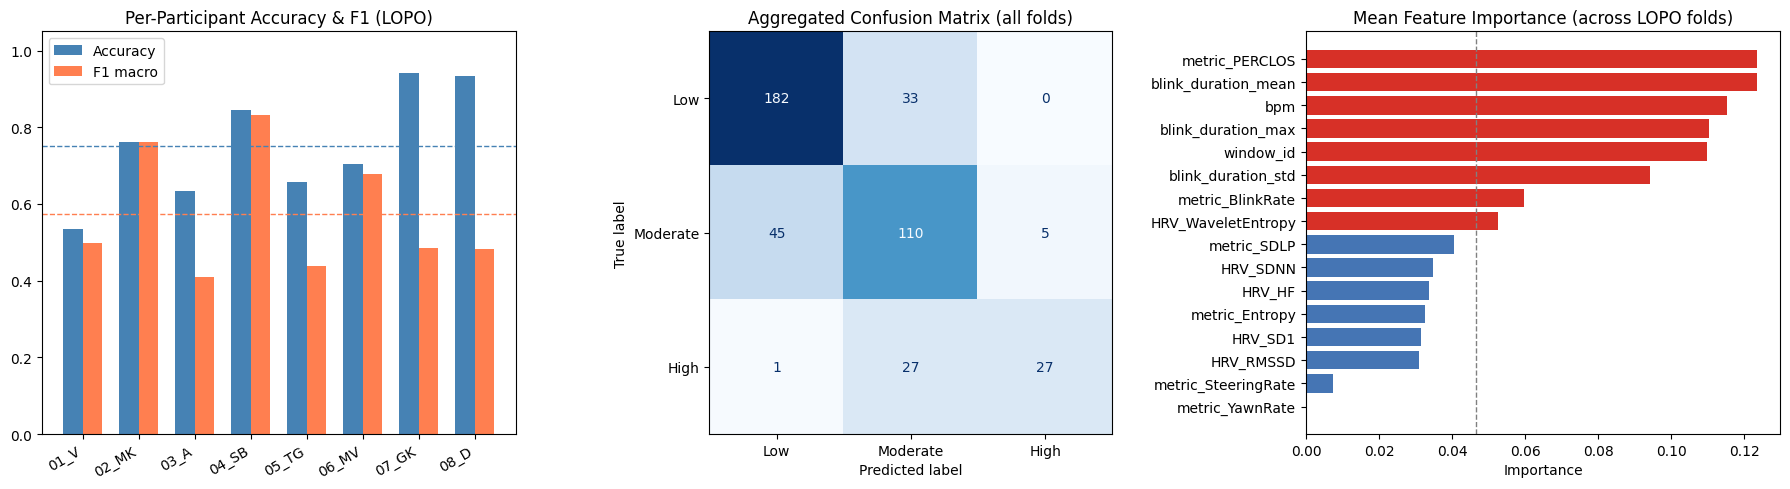

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Per-participant accuracy & F1 ---
x = np.arange(len(results_df))
w = 0.35
axes[0].bar(x - w/2, results_df["accuracy"], w, label="Accuracy", color="steelblue")
axes[0].bar(x + w/2, results_df["f1_macro"],  w, label="F1 macro",  color="coral")
axes[0].axhline(results_df["accuracy"].mean(), color="steelblue", linestyle="--", linewidth=1)
axes[0].axhline(results_df["f1_macro"].mean(),  color="coral",     linestyle="--", linewidth=1)
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_df["participant"], rotation=30, ha="right")
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Per-Participant Accuracy & F1 (LOPO)")
axes[0].legend()

# --- Aggregate confusion matrix ---
cm = confusion_matrix(all_y_true, all_y_pred, labels=[1, 2, 3])
disp = ConfusionMatrixDisplay(cm, display_labels=["Low", "Moderate", "High"])
disp.plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("Aggregated Confusion Matrix (all folds)")

# --- Mean feature importances ---
mean_imp = np.mean(feature_importances, axis=0)
imp_df = pd.Series(mean_imp, index=FEATURES).sort_values()
colors = ["#d73027" if v >= imp_df.median() else "#4575b4" for v in imp_df.values]
axes[2].barh(imp_df.index, imp_df.values, color=colors)
axes[2].axvline(imp_df.median(), color="gray", linestyle="--", linewidth=1)
axes[2].set_title("Mean Feature Importance (across LOPO folds)")
axes[2].set_xlabel("Importance")

plt.tight_layout()
plt.show()

## 4. Per-participant prediction timeline
Shows true vs predicted label over time for each participant.

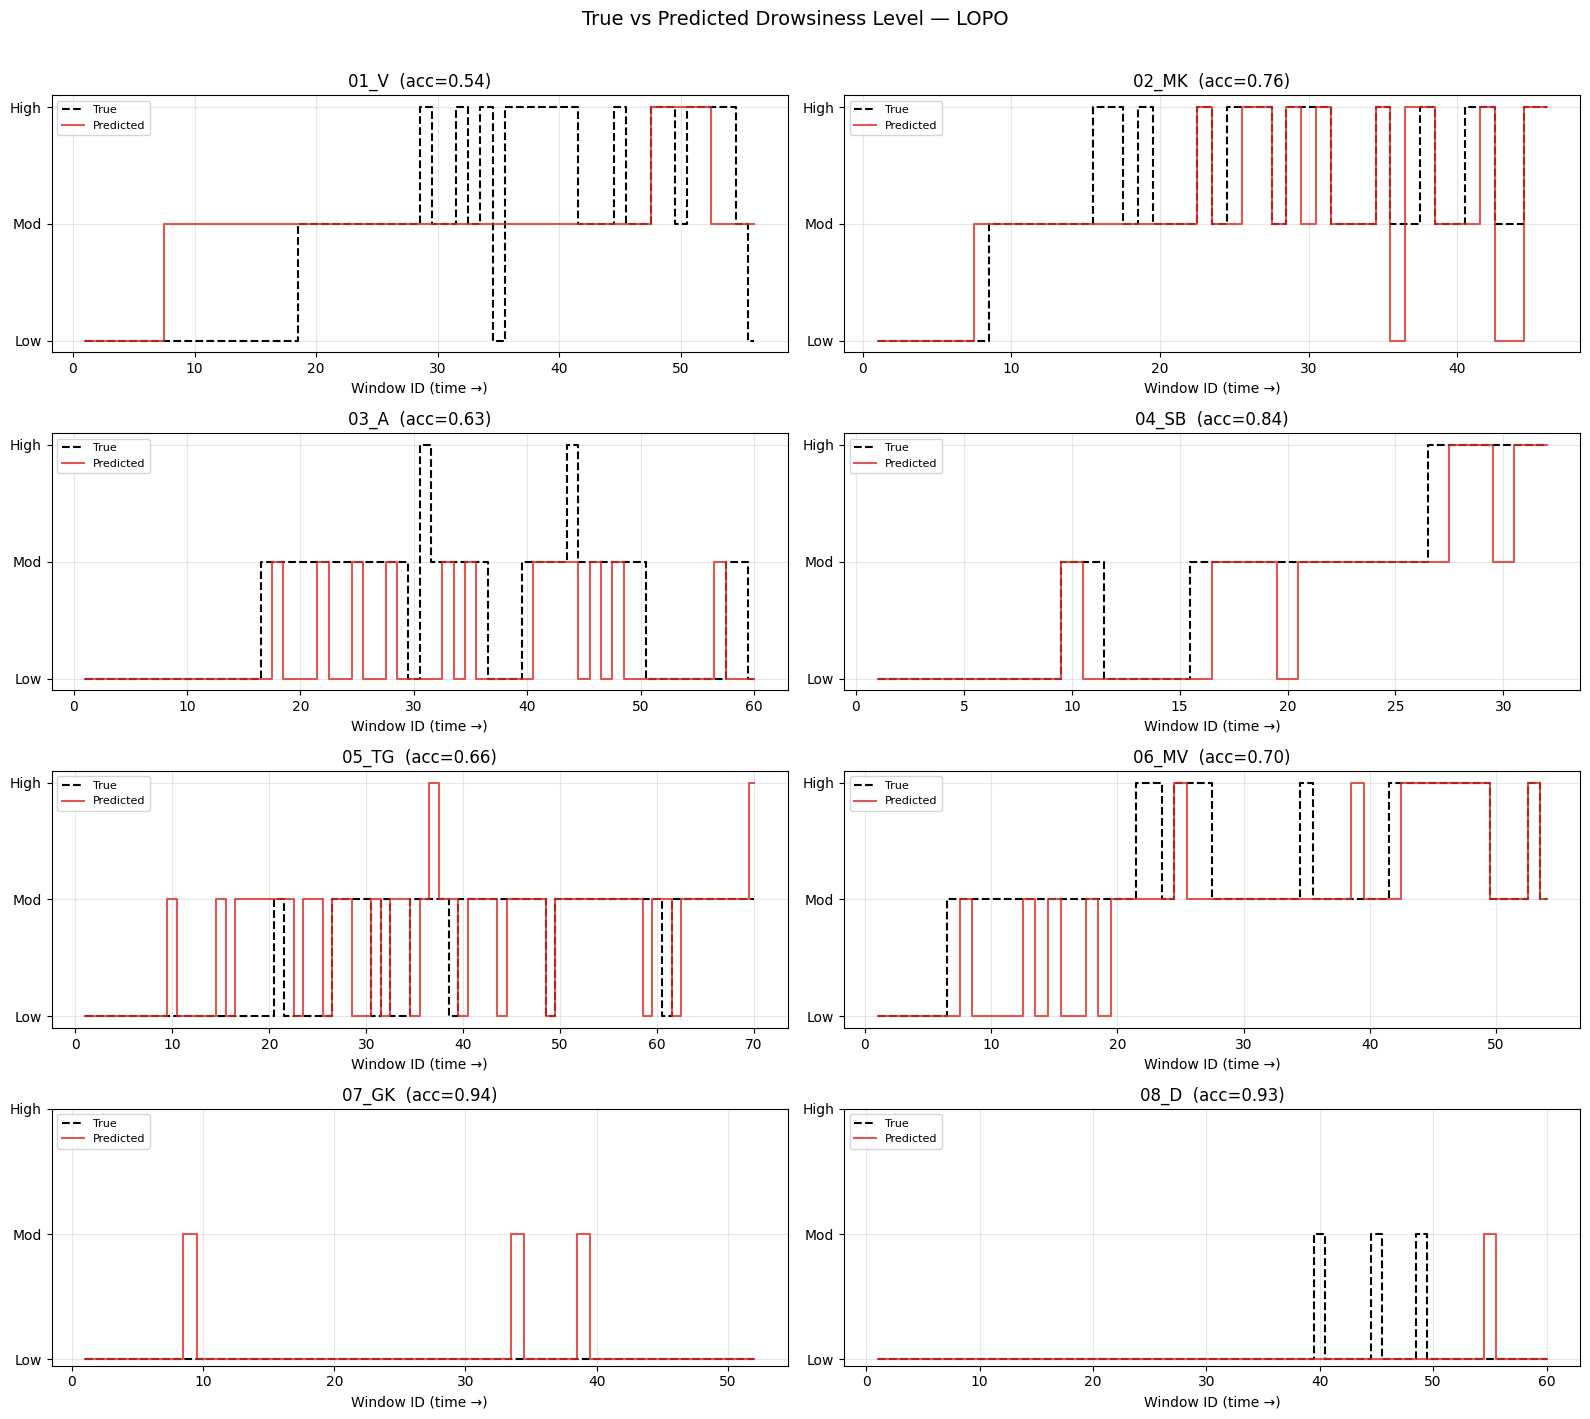

In [6]:
fig, axes = plt.subplots(4, 2, figsize=(16, 14), sharex=False)
axes = axes.flatten()
label_names = {1: "Low", 2: "Moderate", 3: "High"}
colors_true = {1: "#2166ac", 2: "#fdae61", 3: "#d73027"}

for ax, test_pid in zip(axes, participants):
    train_df = all_data[all_data["participant_id"] != test_pid].copy()
    test_df  = all_data[all_data["participant_id"] == test_pid].copy()

    X_train = train_df[FEATURES].fillna(train_df[FEATURES].mean())
    X_test  = test_df[FEATURES].fillna(train_df[FEATURES].mean())
    y_train = train_df["drowsiness_level"]
    y_test  = test_df["drowsiness_level"].values

    scaler = StandardScaler().fit(X_train)
    model = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1)
    model.fit(scaler.transform(X_train), y_train)
    y_pred = model.predict(scaler.transform(X_test))

    windows = test_df["window_id"].values
    ax.step(windows, y_test, where="mid", label="True",      color="black",   linewidth=1.5, linestyle="--")
    ax.step(windows, y_pred, where="mid", label="Predicted", color="#d73027", linewidth=1.5, alpha=0.8)
    ax.set_yticks([1, 2, 3])
    ax.set_yticklabels(["Low", "Mod", "High"])
    ax.set_title(f"{test_pid}  (acc={accuracy_score(y_test, y_pred):.2f})")
    ax.set_xlabel("Window ID (time →)")
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(True, alpha=0.3)

plt.suptitle("True vs Predicted Drowsiness Level — LOPO", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. XGBoost LOPO Cross-Validation

In [7]:
from xgboost import XGBClassifier

xgb_fold_results = []
xgb_all_y_true, xgb_all_y_pred = [], []
xgb_feature_importances = []

for test_pid in participants:
    train_df = all_data[all_data["participant_id"] != test_pid].copy()
    test_df  = all_data[all_data["participant_id"] == test_pid].copy()

    X_train = train_df[FEATURES].copy()
    y_train = train_df["drowsiness_level"].astype(int) - 1   # XGBoost needs 0-indexed labels
    X_test  = test_df[FEATURES].copy()
    y_test  = test_df["drowsiness_level"].astype(int) - 1

    train_means = X_train.mean()
    X_train = X_train.fillna(train_means)
    X_test  = X_test.fillna(train_means)

    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s  = scaler.transform(X_test)

    # Class weights to handle imbalance
    classes, counts = np.unique(y_train, return_counts=True)
    weight_map = {c: len(y_train) / (len(classes) * cnt) for c, cnt in zip(classes, counts)}
    sample_weights = np.array([weight_map[y] for y in y_train])

    model = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1,
        verbosity=0,
    )
    model.fit(X_train_s, y_train, sample_weight=sample_weights)
    y_pred = model.predict(X_test_s)

    # Convert back to 1-indexed for reporting
    y_test_orig = y_test + 1
    y_pred_orig = y_pred + 1

    acc = accuracy_score(y_test_orig, y_pred_orig)
    f1  = f1_score(y_test_orig, y_pred_orig, average="macro", zero_division=0)

    xgb_fold_results.append({"participant": test_pid, "accuracy": acc, "f1_macro": f1})
    xgb_all_y_true.extend(y_test_orig.tolist())
    xgb_all_y_pred.extend(y_pred_orig.tolist())
    xgb_feature_importances.append(model.feature_importances_)

    print(f"[{test_pid}]  acc={acc:.3f}  f1={f1:.3f}")
    print(classification_report(
        y_test_orig, y_pred_orig,
        labels=[1, 2, 3],
        target_names=["Low", "Moderate", "High"],
        zero_division=0,
    ))
    print("-" * 50)

xgb_results_df = pd.DataFrame(xgb_fold_results)
print(f"\nMean accuracy : {xgb_results_df['accuracy'].mean():.3f} ± {xgb_results_df['accuracy'].std():.3f}")
print(f"Mean F1 macro : {xgb_results_df['f1_macro'].mean():.3f} ± {xgb_results_df['f1_macro'].std():.3f}")

[01_V]  acc=0.536  f1=0.467
              precision    recall  f1-score   support

         Low       1.00      0.40      0.57        20
    Moderate       0.43      1.00      0.61        20
        High       1.00      0.12      0.22        16

    accuracy                           0.54        56
   macro avg       0.81      0.51      0.47        56
weighted avg       0.80      0.54      0.48        56

--------------------------------------------------
[02_MK]  acc=0.739  f1=0.732
              precision    recall  f1-score   support

         Low       0.50      0.88      0.64         8
    Moderate       0.76      0.73      0.74        22
        High       1.00      0.69      0.81        16

    accuracy                           0.74        46
   macro avg       0.75      0.76      0.73        46
weighted avg       0.80      0.74      0.75        46

--------------------------------------------------
[03_A]  acc=0.600  f1=0.406
              precision    recall  f1-score   suppo

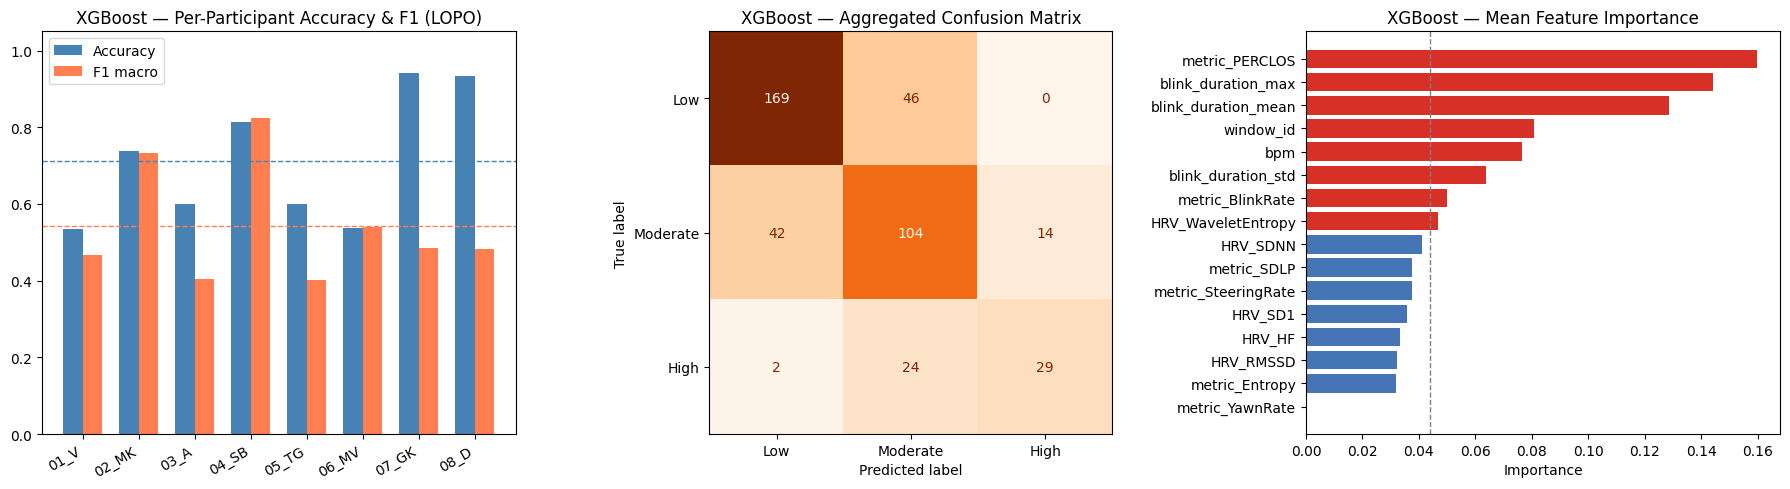

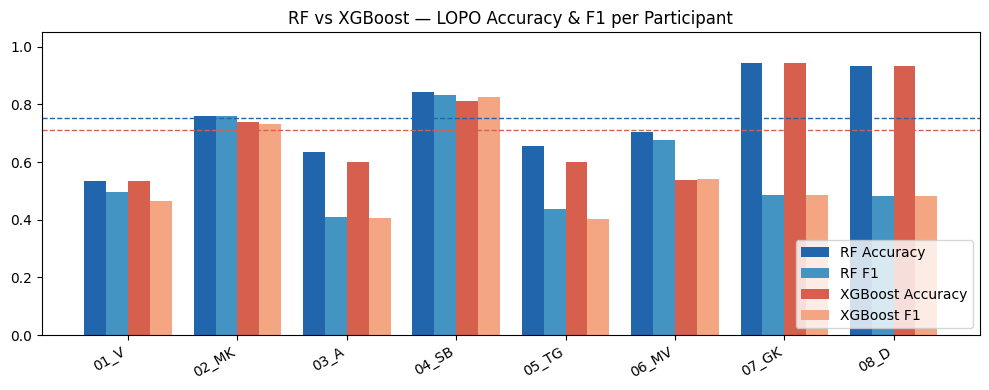

RF   — mean acc: 0.751  mean F1: 0.573
XGB  — mean acc: 0.713  mean F1: 0.542


In [8]:
## XGBoost results + RF vs XGBoost comparison

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Per-participant accuracy & F1 ---
x = np.arange(len(xgb_results_df))
w = 0.35
axes[0].bar(x - w/2, xgb_results_df["accuracy"], w, label="Accuracy", color="steelblue")
axes[0].bar(x + w/2, xgb_results_df["f1_macro"],  w, label="F1 macro",  color="coral")
axes[0].axhline(xgb_results_df["accuracy"].mean(), color="steelblue", linestyle="--", linewidth=1)
axes[0].axhline(xgb_results_df["f1_macro"].mean(),  color="coral",     linestyle="--", linewidth=1)
axes[0].set_xticks(x)
axes[0].set_xticklabels(xgb_results_df["participant"], rotation=30, ha="right")
axes[0].set_ylim(0, 1.05)
axes[0].set_title("XGBoost — Per-Participant Accuracy & F1 (LOPO)")
axes[0].legend()

# --- Aggregate confusion matrix ---
cm = confusion_matrix(xgb_all_y_true, xgb_all_y_pred, labels=[1, 2, 3])
disp = ConfusionMatrixDisplay(cm, display_labels=["Low", "Moderate", "High"])
disp.plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("XGBoost — Aggregated Confusion Matrix")

# --- Mean feature importances ---
mean_imp = np.mean(xgb_feature_importances, axis=0)
imp_df = pd.Series(mean_imp, index=FEATURES).sort_values()
colors = ["#d73027" if v >= imp_df.median() else "#4575b4" for v in imp_df.values]
axes[2].barh(imp_df.index, imp_df.values, color=colors)
axes[2].axvline(imp_df.median(), color="gray", linestyle="--", linewidth=1)
axes[2].set_title("XGBoost — Mean Feature Importance")
axes[2].set_xlabel("Importance")

plt.tight_layout()
plt.show()

# --- RF vs XGBoost side-by-side ---
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(participants))
w = 0.2
ax.bar(x - 1.5*w, results_df["accuracy"],     w, label="RF Accuracy",     color="#2166ac")
ax.bar(x - 0.5*w, results_df["f1_macro"],     w, label="RF F1",           color="#4393c3")
ax.bar(x + 0.5*w, xgb_results_df["accuracy"], w, label="XGBoost Accuracy",color="#d6604d")
ax.bar(x + 1.5*w, xgb_results_df["f1_macro"], w, label="XGBoost F1",      color="#f4a582")
ax.set_xticks(x)
ax.set_xticklabels(participants, rotation=30, ha="right")
ax.set_ylim(0, 1.05)
ax.axhline(results_df["accuracy"].mean(),     color="#2166ac", linestyle="--", linewidth=1)
ax.axhline(xgb_results_df["accuracy"].mean(), color="#d6604d", linestyle="--", linewidth=1)
ax.set_title("RF vs XGBoost — LOPO Accuracy & F1 per Participant")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"RF   — mean acc: {results_df['accuracy'].mean():.3f}  mean F1: {results_df['f1_macro'].mean():.3f}")
print(f"XGB  — mean acc: {xgb_results_df['accuracy'].mean():.3f}  mean F1: {xgb_results_df['f1_macro'].mean():.3f}")


In [9]:
pip install xgboost

/home/karthik/Desktop/llm_eval/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.
